# Exploratory Data Analysis - Credit Card Data
This notebook performs the Exploratory Data Analysis (EDA) for the highly imbalanced Credit Card fraud dataset, analyzing transaction amounts, times, and PCA-reduced features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add src directory to path
sys.path.append(os.path.abspath('../'))
from src.data_preprocessor import load_data, clean_creditcard_data

# Configure plots
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
os.makedirs('../reports/figures', exist_ok=True)

## 1. Load and Clean Data
We load the credit card dataset and remove duplicates.

In [2]:
credit_raw = load_data('../data/raw/creditcard.csv')

# Clean data (removes 1081 duplicates)
credit = clean_creditcard_data(credit_raw)

print('Cleaned credit card shape:', credit.shape)
credit.head()

Removed 1081 duplicate rows from Credit Card data.
Cleaned credit card shape: (283726, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Target Variable Distribution (Class Imbalance)
Let's look at the level of class imbalance in the credit card dataset.

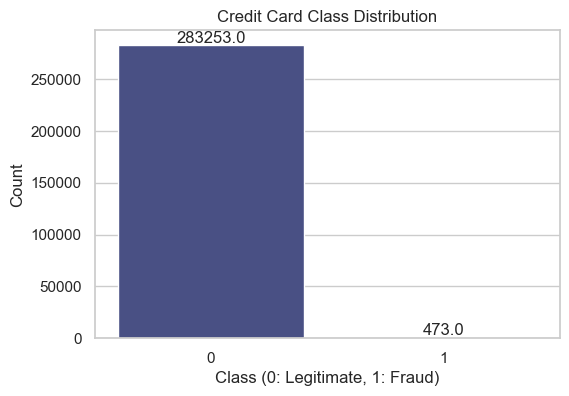

In [3]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Class', data=credit, hue='Class', palette='mako', legend=False)
plt.title('Credit Card Class Distribution')
plt.xlabel('Class (0: Legitimate, 1: Fraud)')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.savefig('../reports/figures/credit_class_dist.png', bbox_inches='tight')
plt.show()

## 3. Transaction Time and Amount Distributions
Since the PCA components (V1-V28) are standardized, let's look at the original features `Time` and `Amount`.

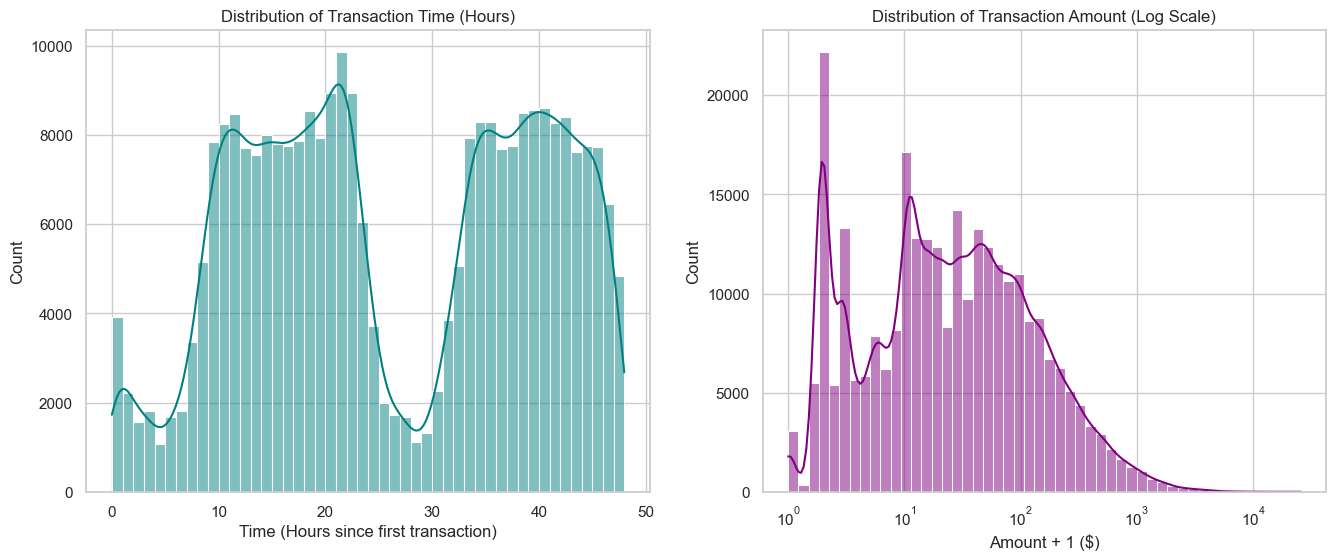

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(credit['Time'] / 3600, kde=True, bins=48, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Transaction Time (Hours)')
axes[0].set_xlabel('Time (Hours since first transaction)')

# Since amount is highly skewed, use log scale
sns.histplot(credit['Amount'] + 1, kde=True, bins=50, ax=axes[1], log_scale=True, color='purple')
axes[1].set_title('Distribution of Transaction Amount (Log Scale)')
axes[1].set_xlabel('Amount + 1 ($)')

plt.savefig('../reports/figures/credit_time_amount_dist.png', bbox_inches='tight')
plt.show()

## 4. Correlation with Target Class
Let's see which PCA components are most strongly correlated (positively or negatively) with the target Class.

In [5]:
correlations = credit.corr()['Class'].sort_values()
print('Top 5 Negative Correlations with Class:')
print(correlations.head(5))
print('\nTop 5 Positive Correlations with Class (excluding Class):')
print(correlations.tail(6)[:-1])

Top 5 Negative Correlations with Class:
V17   -0.313498
V14   -0.293375
V12   -0.250711
V10   -0.206971
V16   -0.187186
Name: Class, dtype: float64

Top 5 Positive Correlations with Class (excluding Class):
V8     0.033068
V19    0.033631
V2     0.084624
V4     0.129326
V11    0.149067
Name: Class, dtype: float64


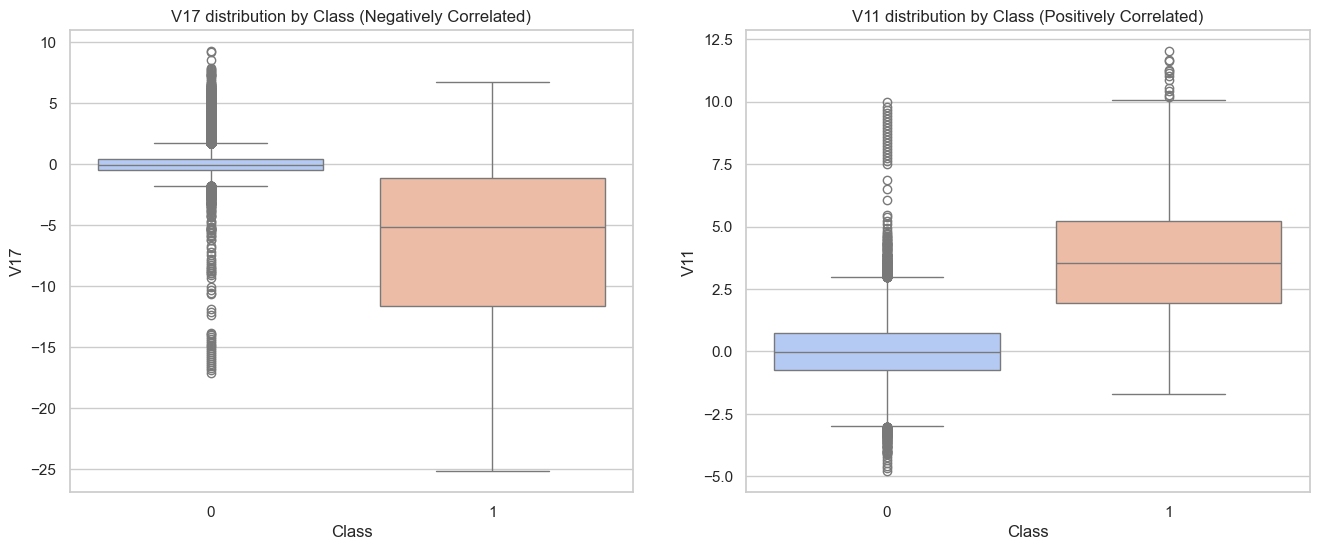

In [6]:
# Visualizing distributions of top correlated PCA features
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# V17 has strong negative correlation
sns.boxplot(x='Class', y='V17', data=credit, ax=axes[0], hue='Class', palette='coolwarm', legend=False)
axes[0].set_title('V17 distribution by Class (Negatively Correlated)')

# V11 has strong positive correlation
sns.boxplot(x='Class', y='V11', data=credit, ax=axes[1], hue='Class', palette='coolwarm', legend=False)
axes[1].set_title('V11 distribution by Class (Positively Correlated)')

plt.savefig('../reports/figures/credit_correlated_features.png', bbox_inches='tight')
plt.show()

## 5. Class Imbalance Quantification
Let's quantify the imbalance in detail.

In [7]:
legit_count = (credit['Class'] == 0).sum()
fraud_count = (credit['Class'] == 1).sum()
total = len(credit)

print(f'Legitimate credit card transactions: {legit_count} ({legit_count/total*100:.4f}%)')
print(f'Fraudulent credit card transactions: {fraud_count} ({fraud_count/total*100:.4f}%)')
print(f'Class ratio (Legit/Fraud): {legit_count/fraud_count:.2f}:1')

Legitimate credit card transactions: 283253 (99.8333%)
Fraudulent credit card transactions: 473 (0.1667%)
Class ratio (Legit/Fraud): 598.84:1


## Summary of EDA Insights (Credit Card)
1. **Extreme Class Imbalance**: The credit card dataset has a massive imbalance, with only 0.17% of transactions (473 out of 283,726 unique transactions) being fraudulent. Traditional learning algorithms will be highly biased toward predicting the majority class unless class balancing is performed.
2. **Transaction Time**: The time feature has a bimodal distribution corresponding to day-night cycles (2 days of data). Fraud occurs relatively evenly across time, unlike legitimate transactions which drop during the night.
3. **Transaction Amount**: Legitimate transaction amounts have a long tail, but the median is around $22. Fraudulent transactions also have a wide range of amounts but do not exhibit massive multi-thousand-dollar values (most are under $500).
4. **Correlations**: PCA components like `V17`, `V14`, `V12`, `V10` are strongly negatively correlated with fraud (i.e. lower values indicate higher fraud probability), while `V11`, `V4`, `V2` are positively correlated.